In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv("literacy_rate_data.csv")

In [2]:
data.isnull().sum()

State/UT            0
Expenditure         0
Schools_per_1000    0
Literacy_Rate       0
dtype: int64

In [3]:
data[["Expenditure", "Schools_per_1000"]].skew()

Expenditure         0.294173
Schools_per_1000    0.163415
dtype: float64

In [4]:
data["Expenditure"]=np.log(data["Expenditure"])
data.head()

,State/UT,Expenditure,Schools_per_1000,Literacy_Rate
0,Andhra Pradesh,16.412378,3.464459,63.2
1,Arunachal Pradesh,15.018472,7.942123,81.9
2,Assam,17.064092,2.412662,87.0
3,Bihar,16.867326,12.911845,71.0
4,Chhattisgarh,15.587517,5.105360,76.1


In [5]:
X=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

In [6]:
X

array([['Andhra Pradesh', 16.412378448115795, 3.464458818],
       ['Arunachal Pradesh', 15.018472158295738, 7.942122921],
       ['Assam', 17.06409239715041, 2.412662253],
       ['Bihar', 16.867326225787235, 12.91184482],
       ['Chhattisgarh', 15.587516724829655, 5.105359779],
       ['Delhi', 15.587375257491168, 9.950267412],
       ['Goa', 14.733353931865729, 5.740532913],
       ['Gujarat', 17.229396334729742, 8.240816254],
       ['Haryana', 16.871324619438802, 8.560523352],
       ['Himachal Pradesh', 17.031522442868695, 4.218253466],
       ['Jharkhand', 14.006267315708293, 13.63501553],
       ['Karnataka', 17.34074956862458, 11.30159388],
       ['Kerala', 17.190339019074944, 13.2739873],
       ['Madhya Pradesh', 15.872923660109716, 12.73792821],
       ['Maharashtra', 17.321057251289783, 9.174799746],
       ['Manipur', 15.736462627731765, 13.06249082],
       ['Mizoram', 16.213074628648553, 3.061910025],
       ['Nagaland', 16.738892377332345, 4.351794349],
       ['Odis

In [7]:
y

array([63.2, 81.9, 87. , 71. , 76.1, 93.1, 87.9, 80.3, 75.5, 85.8, 69.3,
       74.4, 92.9, 72.3, 78.5, 87.6, 99.8, 95.6, 73.6, 76.4, 67. , 83.5,
       79. , 62.3, 91.1, 79.3, 71.2, 78.1, 84. , 93. , 76.9, 67.7, 99.4,
       85. ])

In [8]:
X = data.iloc[:,1:-1].values
X

array([[16.41237845,  3.46445882],
       [15.01847216,  7.94212292],
       [17.0640924 ,  2.41266225],
       [16.86732623, 12.91184482],
       [15.58751672,  5.10535978],
       [15.58737526,  9.95026741],
       [14.73335393,  5.74053291],
       [17.22939633,  8.24081625],
       [16.87132462,  8.56052335],
       [17.03152244,  4.21825347],
       [14.00626732, 13.63501553],
       [17.34074957, 11.30159388],
       [17.19033902, 13.2739873 ],
       [15.87292366, 12.73792821],
       [17.32105725,  9.17479975],
       [15.73646263, 13.06249082],
       [16.21307463,  3.06191002],
       [16.73889238,  4.35179435],
       [16.55001463,  2.54272747],
       [16.17139045,  5.90396397],
       [16.88861698,  6.66412748],
       [15.48558028,  5.25618838],
       [16.17438055, 11.94485011],
       [16.39113227,  6.28103992],
       [16.6026439 ,  5.37121412],
       [17.13291214,  8.512353  ],
       [17.29328171,  3.6910907 ],
       [16.7191872 , 11.62636377],
       [16.8570907 ,

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred = model.predict(X_test)

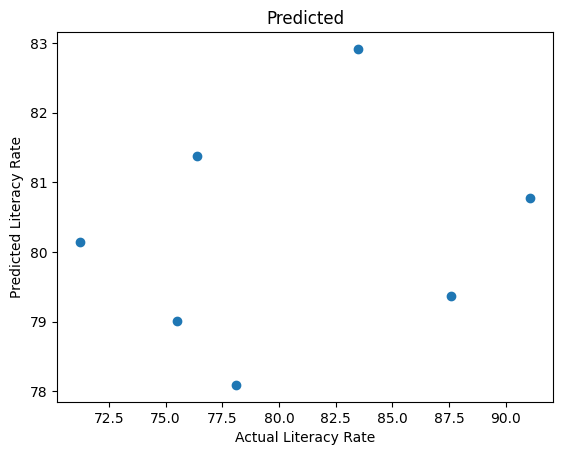

In [17]:
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate")
plt.title("Predicted")
plt.show()

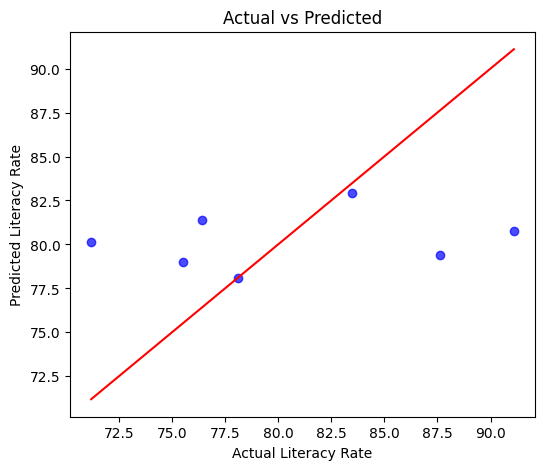

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.xlabel("Actual Literacy Rate")
plt.ylabel("Predicted Literacy Rate")
plt.title("Actual vs Predicted")
plt.show()

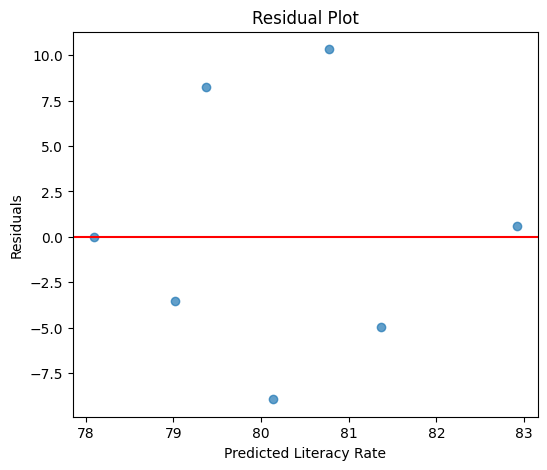

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red')
plt.xlabel("Predicted Literacy Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [14]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("Train R2:", model.score(X_train, y_train))
print("Test R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

Train R2: 0.04383571043643708
Test R2: 0.046313505131155286
RMSE: 6.454949134650317
MAE: 5.224582410374383
